<a href="https://colab.research.google.com/github/vyshnaviperumalla15/git-demoai1/blob/master/PRODIGY_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

print("Dataset loaded ")

Dataset loaded 


In [ ]:
# select only cats and dogs
train_filter = np.where((train_labels == 3) | (train_labels == 5))[0]
test_filter = np.where((test_labels == 3) | (test_labels == 5))[0]

X = train_images[train_filter]
y = train_labels[train_filter]

X_test = test_images[test_filter]
y_test = test_labels[test_filter]

# convert labels: cat=0, dog=1
y = (y == 5).astype(int)
y_test = (y_test == 5).astype(int)

print("Filtered dataset ready ")

Filtered dataset ready 


In [ ]:
IMG_SIZE = 50

def process(images):
    new_data = []
    for img in images:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        new_data.append(img)
    return np.array(new_data)

X = process(X)
X_test = process(X_test)

# flatten
X = X.reshape(len(X), -1)
X_test = X_test.reshape(len(X_test), -1)

print("Preprocessing done ")

Preprocessing done 


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# fix label shape
y = y.ravel()

# SUPER FAST model
model = make_pipeline(
    StandardScaler(),
    SGDClassifier(max_iter=1000)
)

model.fit(X, y)

print("Model trained ultra fast ⚡")

Model trained ultra fast ⚡


In [ ]:
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.497


Predicted: Dog 


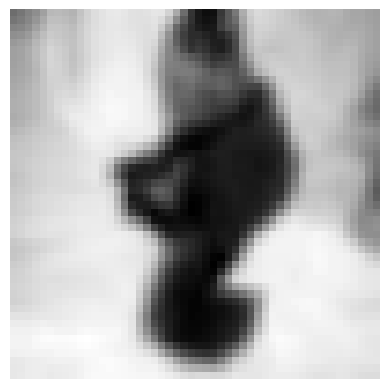

In [ ]:
import random
import matplotlib.pyplot as plt

# pick random image
index = random.randint(0, len(X_test)-1)

sample = X_test[index]
prediction = model.predict([sample])

if prediction[0] == 0:
    print("Predicted: Cat ")
else:
    print("Predicted: Dog ")

# show image
plt.imshow(sample.reshape(50,50), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[498 502]
 [504 496]]
